# Color Space Conversions
Rayya Syauqi Alulu'i
103012300268

Implementasi konversi warna secara manual antara:
- **RGB ↔ HSV**
- **RGB ↔ CMYK**
- **RGB ↔ YCbCr**

Setiap bagian mencakup:
1. Konversi maju (RGB → color space)
2. Konversi balik (color space → RGB)
3. Visualisasi channel individual

## 1. Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from io import BytesIO

print("Import libraries successfully.")

Import libraries successfully.


## 2. Load Colorful Example Image

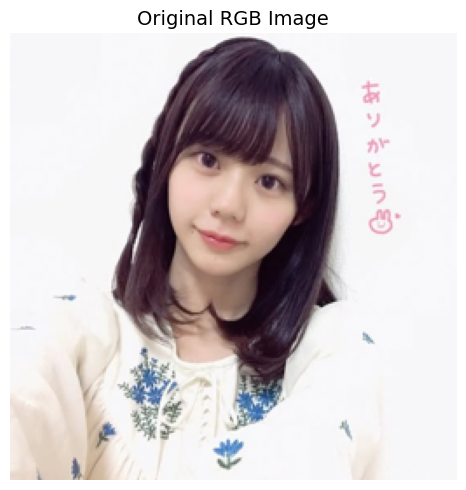

Image shape: (256, 256, 3), dtype: float64
Value range: [0.000, 1.000]


In [2]:
def load_example_image():
    """Load a colorful example image from the local directory, fallback to synthetic."""
    try:
        img = Image.open("hanekawa_mei.jpg").convert("RGB")
        img = img.resize((256, 256))
        return np.array(img, dtype=np.float64) / 255.0
    except Exception:
        pass

    # Fallback: synthetic colorful image
    print("Using synthetic colorful image if local image is not found.")
    h, w = 256, 256
    img = np.zeros((h, w, 3), dtype=np.float64)
    for y in range(h):
        for x in range(w):
            img[y, x, 0] = x / w                      # Red gradient
            img[y, x, 1] = y / h                      # Green gradient
            img[y, x, 2] = 1 - (x + y) / (w + h)     # Blue gradient
    return img

# Load image (values in [0, 1])
img_rgb = load_example_image()

plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title("Original RGB Image", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()
print(f"Image shape: {img_rgb.shape}, dtype: {img_rgb.dtype}")
print(f"Value range: [{img_rgb.min():.3f}, {img_rgb.max():.3f}]")

In [3]:
# print the matrix of the image
print("Image array (first 5 rows):")
img_rgb

Image array (first 5 rows):


array([[[0.96862745, 0.96862745, 0.97647059],
        [0.96862745, 0.96862745, 0.97647059],
        [0.96862745, 0.96862745, 0.97647059],
        ...,
        [0.96862745, 0.96862745, 0.97647059],
        [0.96862745, 0.96862745, 0.97647059],
        [0.96862745, 0.96862745, 0.97647059]],

       [[0.96862745, 0.96862745, 0.97647059],
        [0.96862745, 0.96862745, 0.97647059],
        [0.96862745, 0.96862745, 0.97647059],
        ...,
        [0.96862745, 0.96862745, 0.97647059],
        [0.96862745, 0.96862745, 0.97647059],
        [0.96862745, 0.96862745, 0.97647059]],

       [[0.96862745, 0.96862745, 0.97647059],
        [0.96862745, 0.96862745, 0.97647059],
        [0.96862745, 0.96862745, 0.97647059],
        ...,
        [0.96862745, 0.96862745, 0.97647059],
        [0.96862745, 0.96862745, 0.97647059],
        [0.96862745, 0.96862745, 0.97647059]],

       ...,

       [[0.90588235, 0.83921569, 0.8       ],
        [0.90588235, 0.83921569, 0.8       ],
        [0.90588235, 0

---
## 3. RGB ↔ HSV Conversion

**Formula:**
- **H** (Hue): angle in [0°, 360°]
- **S** (Saturation): in [0, 1]
- **V** (Value): in [0, 1]

Let `R, G, B ∈ [0,1]`, `Cmax = max(R,G,B)`, `Cmin = min(R,G,B)`, `Δ = Cmax - Cmin`

```
V = Cmax
S = 0                   if Cmax == 0
    Δ / Cmax            otherwise

H = 0                   if Δ == 0
    60 × ((G-B)/Δ mod 6) if Cmax == R
    60 × ((B-R)/Δ + 2)   if Cmax == G
    60 × ((R-G)/Δ + 4)   if Cmax == B
```

In [4]:
def rgb_to_hsv(img):
    """
    Convert RGB image to HSV.
    Input:  img shape (H, W, 3), values in [0, 1]
    Output: hsv shape (H, W, 3)
            H in [0, 360], S in [0, 1], V in [0, 1]
    """
    R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]

    Cmax = np.maximum(np.maximum(R, G), B)
    Cmin = np.minimum(np.minimum(R, G), B)
    delta = Cmax - Cmin

    # Value
    V = Cmax

    # Saturation
    S = np.where(Cmax == 0, 0.0, delta / Cmax)

    # Hue
    eps = 1e-10
    H = np.zeros_like(R)

    mask_r = (Cmax == R) & (delta != 0)
    mask_g = (Cmax == G) & (delta != 0)
    mask_b = (Cmax == B) & (delta != 0)

    H[mask_r] = 60.0 * (((G[mask_r] - B[mask_r]) / (delta[mask_r] + eps)) % 6)
    H[mask_g] = 60.0 * (((B[mask_g] - R[mask_g]) / (delta[mask_g] + eps)) + 2)
    H[mask_b] = 60.0 * (((R[mask_b] - G[mask_b]) / (delta[mask_b] + eps)) + 4)

    H = H % 360.0  # Normalize to [0, 360]

    return np.stack([H, S, V], axis=2)


def hsv_to_rgb(img):
    """
    Convert HSV image back to RGB.
    Input:  img shape (H, W, 3), H in [0,360], S,V in [0,1]
    Output: rgb shape (H, W, 3), values in [0, 1]
    """
    H, S, V = img[:, :, 0], img[:, :, 1], img[:, :, 2]

    C = V * S                        # Chroma
    X = C * (1 - np.abs((H / 60.0) % 2 - 1))
    m = V - C

    R1 = np.zeros_like(H)
    G1 = np.zeros_like(H)
    B1 = np.zeros_like(H)

    sectors = [
        ((H >= 0)   & (H < 60),  C, X, np.zeros_like(H)),
        ((H >= 60)  & (H < 120), X, C, np.zeros_like(H)),
        ((H >= 120) & (H < 180), np.zeros_like(H), C, X),
        ((H >= 180) & (H < 240), np.zeros_like(H), X, C),
        ((H >= 240) & (H < 300), X, np.zeros_like(H), C),
        ((H >= 300) & (H < 360), C, np.zeros_like(H), X),
    ]

    for mask, r, g, b in sectors:
        R1[mask] = r[mask]
        G1[mask] = g[mask]
        B1[mask] = b[mask]

    R = np.clip(R1 + m, 0, 1)
    G = np.clip(G1 + m, 0, 1)
    B = np.clip(B1 + m, 0, 1)

    return np.stack([R, G, B], axis=2)


print("HSV conversion functions defined.")

HSV conversion functions defined.


HSV round-trip mean absolute error: 0.000000
H range: [0.0, 359.3] degrees
S range: [0.000, 1.000]
V range: [0.043, 1.000]


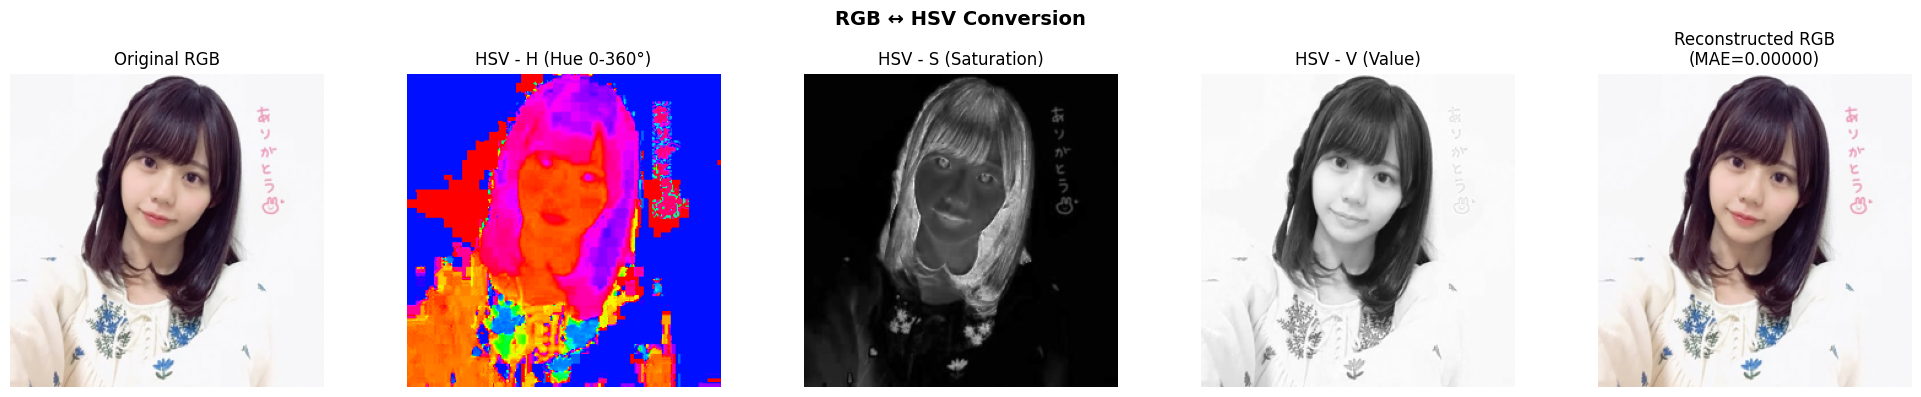

In [5]:
# Convert RGB → HSV → RGB
img_hsv = rgb_to_hsv(img_rgb)
img_rgb_from_hsv = hsv_to_rgb(img_hsv)

# Reconstruction error
error_hsv = np.mean(np.abs(img_rgb - img_rgb_from_hsv))
print(f"HSV round-trip mean absolute error: {error_hsv:.6f}")
print(f"H range: [{img_hsv[:,:,0].min():.1f}, {img_hsv[:,:,0].max():.1f}] degrees")
print(f"S range: [{img_hsv[:,:,1].min():.3f}, {img_hsv[:,:,1].max():.3f}]")
print(f"V range: [{img_hsv[:,:,2].min():.3f}, {img_hsv[:,:,2].max():.3f}]")

# Visualize
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
channel_names = ["H (Hue 0-360°)", "S (Saturation)", "V (Value)"]
cmaps = ["hsv", "gray", "gray"]

axes[0].imshow(img_rgb)
axes[0].set_title("Original RGB", fontsize=12)
axes[0].axis("off")

for i in range(3):
    axes[i + 1].imshow(img_hsv[:, :, i], cmap=cmaps[i],
                       vmin=0, vmax=360 if i == 0 else 1)
    axes[i + 1].set_title(f"HSV - {channel_names[i]}", fontsize=12)
    axes[i + 1].axis("off")

axes[4].imshow(np.clip(img_rgb_from_hsv, 0, 1))
axes[4].set_title(f"Reconstructed RGB\n(MAE={error_hsv:.5f})", fontsize=12)
axes[4].axis("off")

plt.suptitle("RGB ↔ HSV Conversion", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. RGB ↔ CMYK Conversion

**Formula** (R, G, B ∈ [0,1]):

```
K = 1 - max(R, G, B)
C = (1 - R - K) / (1 - K)   if K ≠ 1, else 0
M = (1 - G - K) / (1 - K)   if K ≠ 1, else 0
Y = (1 - B - K) / (1 - K)   if K ≠ 1, else 0

All outputs C, M, Y, K ∈ [0, 1]
```

**Inverse:**
```
R = (1 - C) × (1 - K)
G = (1 - M) × (1 - K)
B = (1 - Y) × (1 - K)
```

In [6]:
def rgb_to_cmyk(img):
    """
    Convert RGB image to CMYK.
    Input:  img shape (H, W, 3), values in [0, 1]
    Output: cmyk shape (H, W, 4), C, M, Y, K all in [0, 1]
    """
    R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]

    K = 1.0 - np.maximum(np.maximum(R, G), B)

    denom = 1.0 - K
    safe = denom > 0

    C = np.where(safe, (1.0 - R - K) / np.where(safe, denom, 1), 0.0)
    M = np.where(safe, (1.0 - G - K) / np.where(safe, denom, 1), 0.0)
    Y = np.where(safe, (1.0 - B - K) / np.where(safe, denom, 1), 0.0)

    C = np.clip(C, 0, 1)
    M = np.clip(M, 0, 1)
    Y = np.clip(Y, 0, 1)
    K = np.clip(K, 0, 1)

    return np.stack([C, M, Y, K], axis=2)


def cmyk_to_rgb(img):
    """
    Convert CMYK image back to RGB.
    Input:  img shape (H, W, 4), C, M, Y, K in [0, 1]
    Output: rgb shape (H, W, 3), values in [0, 1]
    """
    C, M, Y, K = img[:, :, 0], img[:, :, 1], img[:, :, 2], img[:, :, 3]

    R = (1.0 - C) * (1.0 - K)
    G = (1.0 - M) * (1.0 - K)
    B = (1.0 - Y) * (1.0 - K)

    return np.clip(np.stack([R, G, B], axis=2), 0, 1)


print("CMYK conversion functions defined.")

CMYK conversion functions defined.


CMYK round-trip mean absolute error: 0.000000
C range: [0.000, 0.742]
M range: [0.000, 1.000]
Y range: [0.000, 1.000]
K range: [0.000, 0.957]


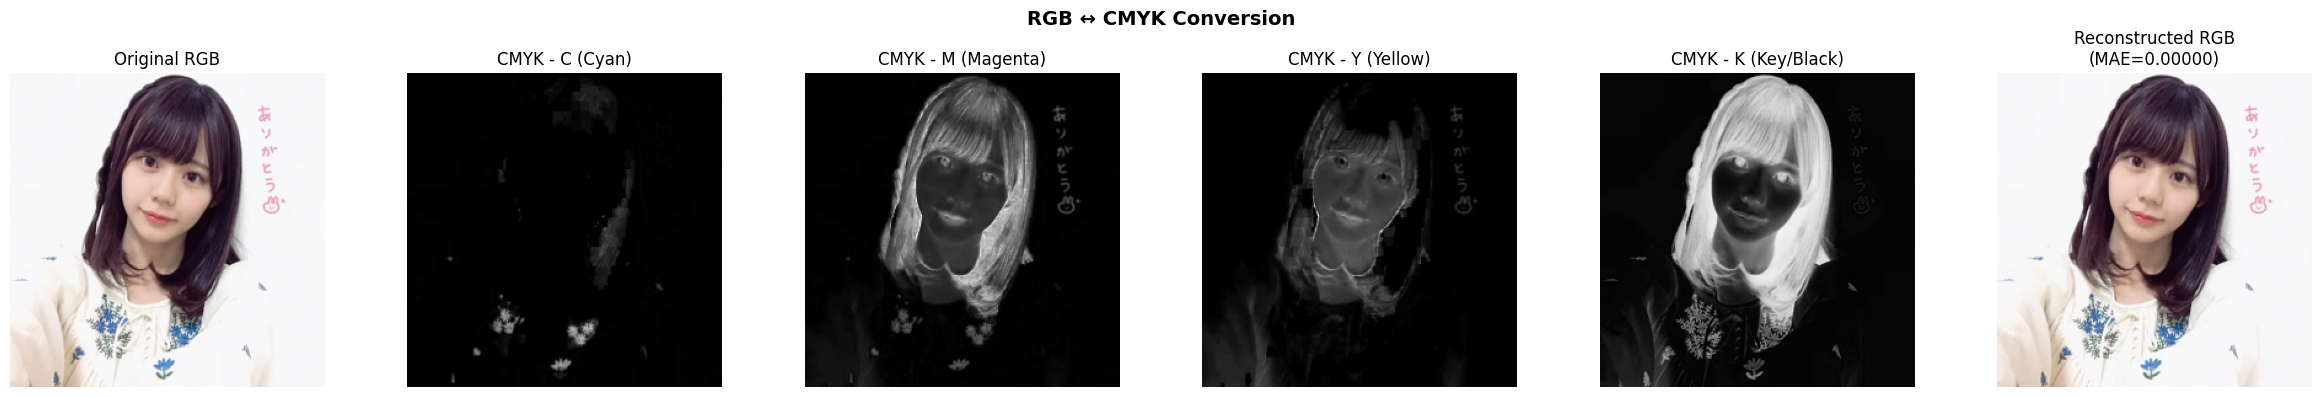

In [7]:
# Convert RGB → CMYK → RGB
img_cmyk = rgb_to_cmyk(img_rgb)
img_rgb_from_cmyk = cmyk_to_rgb(img_cmyk)

error_cmyk = np.mean(np.abs(img_rgb - img_rgb_from_cmyk))
print(f"CMYK round-trip mean absolute error: {error_cmyk:.6f}")
for i, ch in enumerate(["C", "M", "Y", "K"]):
    print(f"{ch} range: [{img_cmyk[:,:,i].min():.3f}, {img_cmyk[:,:,i].max():.3f}]")

# Visualize
fig, axes = plt.subplots(1, 6, figsize=(24, 4))
channel_names = ["C (Cyan)", "M (Magenta)", "Y (Yellow)", "K (Key/Black)"]
cmaps_cmyk = ["cyan", "RdPu", "YlOrBr", "gray"]

axes[0].imshow(img_rgb)
axes[0].set_title("Original RGB", fontsize=12)
axes[0].axis("off")

for i in range(4):
    axes[i + 1].imshow(img_cmyk[:, :, i], cmap="gray", vmin=0, vmax=1)
    axes[i + 1].set_title(f"CMYK - {channel_names[i]}", fontsize=12)
    axes[i + 1].axis("off")

axes[5].imshow(img_rgb_from_cmyk)
axes[5].set_title(f"Reconstructed RGB\n(MAE={error_cmyk:.5f})", fontsize=12)
axes[5].axis("off")

plt.suptitle("RGB ↔ CMYK Conversion", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. RGB ↔ YCbCr Conversion

**Formula** (ITU-R BT.601, R, G, B ∈ [0, 1]):

```
Y  =  0.299R  + 0.587G  + 0.114B
Cb = -0.1687R - 0.3313G + 0.5B   + 0.5
Cr =  0.5R    - 0.4187G - 0.0813B + 0.5

Y  ∈ [0, 1]      (Luma)
Cb ∈ [0, 1]      (Blue-difference chroma, shifted by 0.5)
Cr ∈ [0, 1]      (Red-difference chroma, shifted by 0.5)
```

**Inverse:**
```
R = Y + 1.402 × (Cr - 0.5)
G = Y - 0.344136 × (Cb - 0.5) - 0.714136 × (Cr - 0.5)
B = Y + 1.772 × (Cb - 0.5)
```

In [8]:
def rgb_to_ycbcr(img):
    """
    Convert RGB image to YCbCr (ITU-R BT.601).
    Input:  img shape (H, W, 3), values in [0, 1]
    Output: ycbcr shape (H, W, 3)
            Y in [0, 1], Cb in [0, 1], Cr in [0, 1]
    """
    R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]

    Y  =  0.299   * R + 0.587   * G + 0.114   * B
    Cb = -0.16875 * R - 0.33126 * G + 0.5     * B + 0.5
    Cr =  0.5     * R - 0.41869 * G - 0.08131 * B + 0.5

    Y  = np.clip(Y,  0, 1)
    Cb = np.clip(Cb, 0, 1)
    Cr = np.clip(Cr, 0, 1)

    return np.stack([Y, Cb, Cr], axis=2)


def ycbcr_to_rgb(img):
    """
    Convert YCbCr image back to RGB.
    Input:  img shape (H, W, 3), Y, Cb, Cr in [0, 1]
    Output: rgb shape (H, W, 3), values in [0, 1]
    """
    Y, Cb, Cr = img[:, :, 0], img[:, :, 1], img[:, :, 2]

    R = Y + 1.402    * (Cr - 0.5)
    G = Y - 0.344136 * (Cb - 0.5) - 0.714136 * (Cr - 0.5)
    B = Y + 1.772    * (Cb - 0.5)

    return np.clip(np.stack([R, G, B], axis=2), 0, 1)


print("YCbCr conversion functions defined.")

YCbCr conversion functions defined.


YCbCr round-trip mean absolute error: 0.000006
Y range: [0.013, 1.000]
Cb range: [0.426, 0.678]
Cr range: [0.367, 0.695]


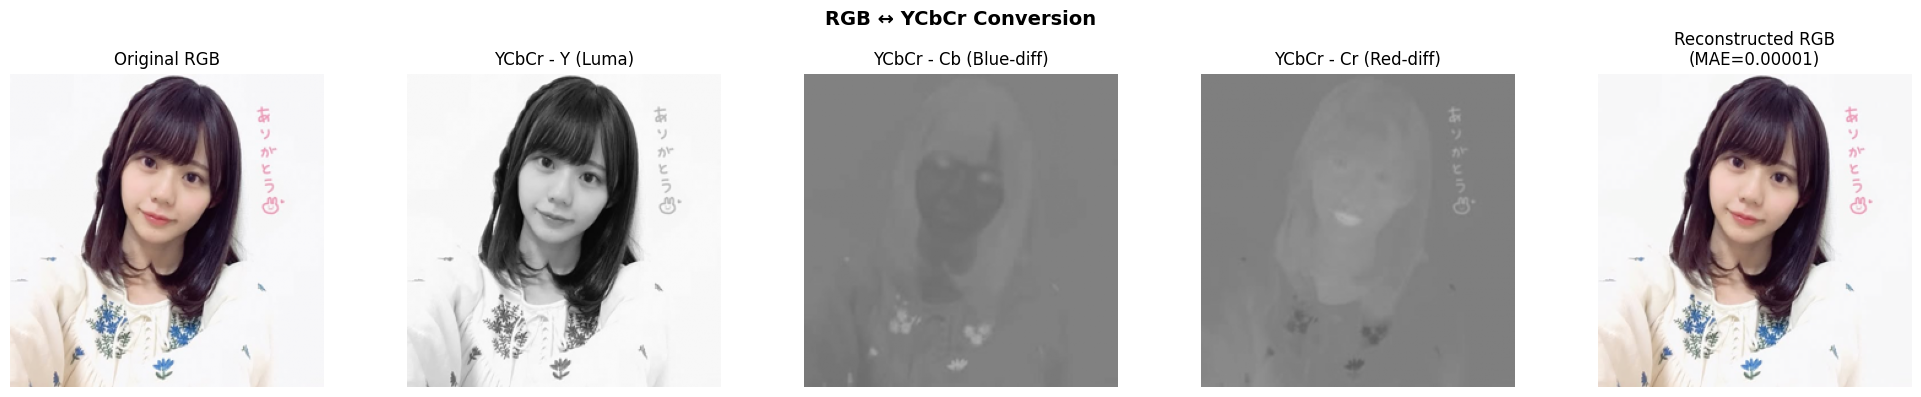

In [9]:
# Convert RGB → YCbCr → RGB
img_ycbcr = rgb_to_ycbcr(img_rgb)
img_rgb_from_ycbcr = ycbcr_to_rgb(img_ycbcr)

error_ycbcr = np.mean(np.abs(img_rgb - img_rgb_from_ycbcr))
print(f"YCbCr round-trip mean absolute error: {error_ycbcr:.6f}")
for i, ch in enumerate(["Y", "Cb", "Cr"]):
    print(f"{ch} range: [{img_ycbcr[:,:,i].min():.3f}, {img_ycbcr[:,:,i].max():.3f}]")

# Visualize
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
channel_names = ["Y (Luma)", "Cb (Blue-diff)", "Cr (Red-diff)"]

axes[0].imshow(img_rgb)
axes[0].set_title("Original RGB", fontsize=12)
axes[0].axis("off")

for i in range(3):
    axes[i + 1].imshow(img_ycbcr[:, :, i], cmap="gray", vmin=0, vmax=1)
    axes[i + 1].set_title(f"YCbCr - {channel_names[i]}", fontsize=12)
    axes[i + 1].axis("off")

axes[4].imshow(img_rgb_from_ycbcr)
axes[4].set_title(f"Reconstructed RGB\n(MAE={error_ycbcr:.5f})", fontsize=12)
axes[4].axis("off")

plt.suptitle("RGB ↔ YCbCr Conversion", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Main Function — Full Pipeline Test

  COLOR SPACE CONVERSION — FULL PIPELINE TEST

Image loaded: shape=(256, 256, 3)

[HSV]   Round-trip MAE = 0.00000000  (✓ PASS)
[CMYK]  Round-trip MAE = 0.00000000  (✓ PASS)
[YCbCr] Round-trip MAE = 0.00000569  (✓ PASS)


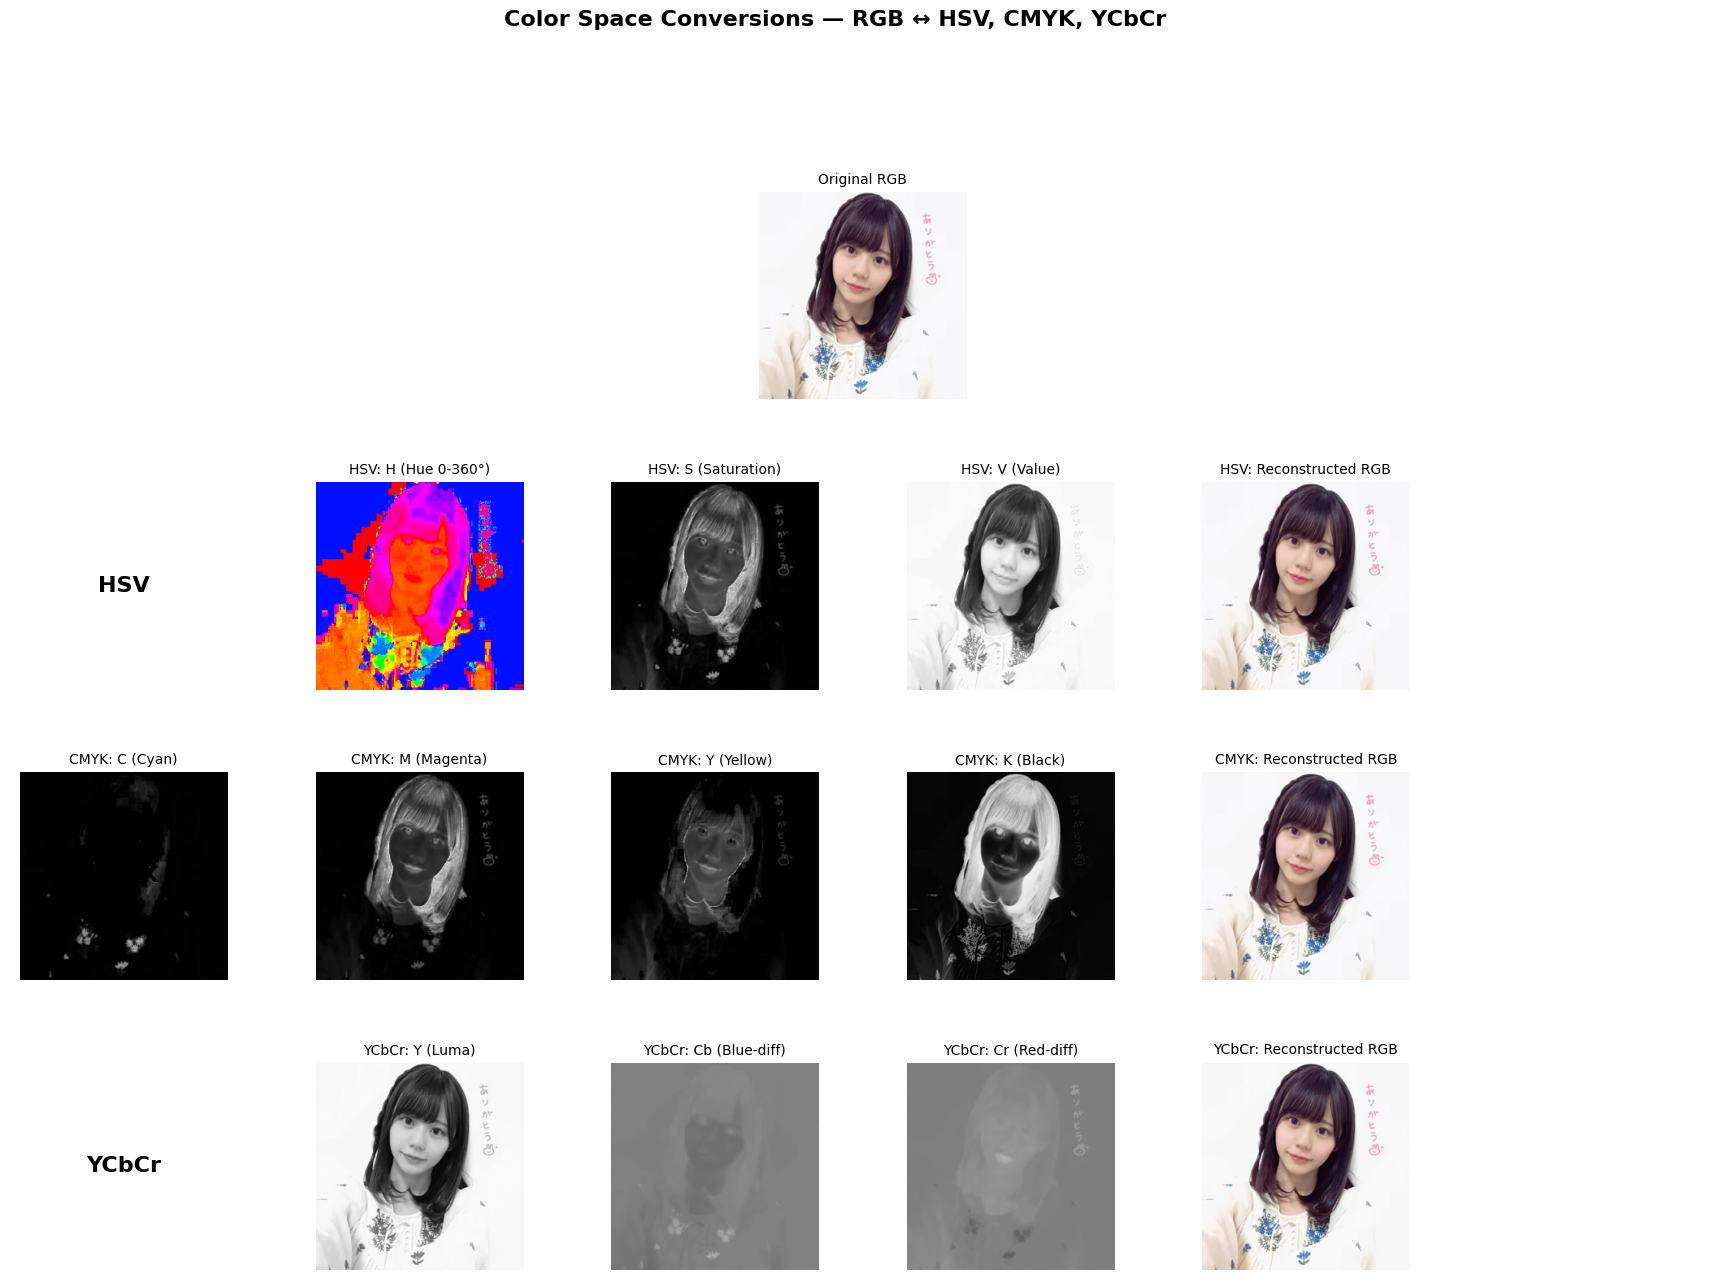


Done! Summary figure saved to /tmp/color_space_summary.png


In [10]:
def main():
    """
    Main function: load image, run all conversions and their inverses,
    verify correctness, and show a comprehensive visualization.
    """
    print("=" * 60)
    print("  COLOR SPACE CONVERSION — FULL PIPELINE TEST")
    print("=" * 60)

    # Load
    img = load_example_image()
    print(f"\nImage loaded: shape={img.shape}")

    # --- HSV ---
    hsv   = rgb_to_hsv(img)
    rgb_h = hsv_to_rgb(hsv)
    err_h = np.mean(np.abs(img - rgb_h))
    print(f"\n[HSV]   Round-trip MAE = {err_h:.8f}  ({'✓ PASS' if err_h < 1e-4 else '✗ FAIL'})")

    # --- CMYK ---
    cmyk  = rgb_to_cmyk(img)
    rgb_c = cmyk_to_rgb(cmyk)
    err_c = np.mean(np.abs(img - rgb_c))
    print(f"[CMYK]  Round-trip MAE = {err_c:.8f}  ({'✓ PASS' if err_c < 1e-4 else '✗ FAIL'})")

    # --- YCbCr ---
    ycbcr = rgb_to_ycbcr(img)
    rgb_y = ycbcr_to_rgb(ycbcr)
    err_y = np.mean(np.abs(img - rgb_y))
    print(f"[YCbCr] Round-trip MAE = {err_y:.8f}  ({'✓ PASS' if err_y < 1e-4 else '✗ FAIL'})")

    # --- Comprehensive Visualization ---
    fig = plt.figure(figsize=(22, 14))
    gs = gridspec.GridSpec(4, 6, figure=fig, hspace=0.4, wspace=0.3)

    def show(ax, data, title, cmap="viridis", vmin=None, vmax=None):
        ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    # Row 0: Original
    ax = fig.add_subplot(gs[0, 2:4])
    show(ax, img, "Original RGB", cmap=None)

    # Row 1: HSV
    labels_hsv = ["H (Hue 0-360°)", "S (Saturation)", "V (Value)", "Reconstructed RGB"]
    channels_hsv = [hsv[:,:,0], hsv[:,:,1], hsv[:,:,2], rgb_h]
    cmaps_hsv = ["hsv", "gray", "gray", None]
    vmins_hsv = [0, 0, 0, None]
    vmaxs_hsv = [360, 1, 1, None]
    for i, (data, label, cm, vn, vx) in enumerate(zip(channels_hsv, labels_hsv, cmaps_hsv, vmins_hsv, vmaxs_hsv)):
        ax = fig.add_subplot(gs[1, i + 1])
        show(ax, data, f"HSV: {label}", cm, vn, vx)

    # Row 2: CMYK
    labels_cmyk = ["C (Cyan)", "M (Magenta)", "Y (Yellow)", "K (Black)", "Reconstructed RGB"]
    channels_cmyk = [cmyk[:,:,0], cmyk[:,:,1], cmyk[:,:,2], cmyk[:,:,3], rgb_c]
    cmaps_cmyk = ["gray"] * 4 + [None]
    for i, (data, label, cm) in enumerate(zip(channels_cmyk, labels_cmyk, cmaps_cmyk)):
        ax = fig.add_subplot(gs[2, i])
        show(ax, data, f"CMYK: {label}", cm, 0 if cm == "gray" else None, 1 if cm == "gray" else None)
    # empty last col
    fig.add_subplot(gs[2, 5]).axis("off")

    # Row 3: YCbCr
    labels_ycbcr = ["Y (Luma)", "Cb (Blue-diff)", "Cr (Red-diff)", "Reconstructed RGB"]
    channels_ycbcr = [ycbcr[:,:,0], ycbcr[:,:,1], ycbcr[:,:,2], rgb_y]
    cmaps_ycbcr = ["gray", "gray", "gray", None]
    for i, (data, label, cm) in enumerate(zip(channels_ycbcr, labels_ycbcr, cmaps_ycbcr)):
        ax = fig.add_subplot(gs[3, i + 1])
        show(ax, data, f"YCbCr: {label}", cm, 0 if cm == "gray" else None, 1 if cm == "gray" else None)

    # Row labels
    for row, label in zip([1, 2, 3], ["HSV", "CMYK", "YCbCr"]):
        ax = fig.add_subplot(gs[row, 0])
        ax.text(0.5, 0.5, label, ha="center", va="center",
                fontsize=16, fontweight="bold",
                transform=ax.transAxes)
        ax.axis("off")

    fig.suptitle("Color Space Conversions — RGB ↔ HSV, CMYK, YCbCr",
                 fontsize=16, fontweight="bold", y=1.01)
    plt.savefig("color_space_summary.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("\nDone! Summary figure saved to /tmp/color_space_summary.png")


# Run
main()

---
## Ringkasan Rumus

| Color Space | Forward (RGB→X) | Inverse (X→RGB) | Channels |
|-------------|-----------------|-----------------|----------|
| **HSV** | Berbasis Cmax, Cmin, Δ | Via chroma & sektor H | H [0°,360°], S [0,1], V [0,1] |
| **CMYK** | K=1-max(R,G,B), CMY=(1-RGB-K)/(1-K) | RGB=(1-CMY)(1-K) | C, M, Y, K ∈ [0,1] |
| **YCbCr** | Matrix BT.601 + offset 0.5 | Invers matrix | Y, Cb, Cr ∈ [0,1] |

> **Catatan:** Semua konversi diimplementasikan secara manual menggunakan rumus matematika tanpa memanggil `cv2.cvtColor` atau fungsi konversi bawaan lainnya.